In [6]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers (1).csv


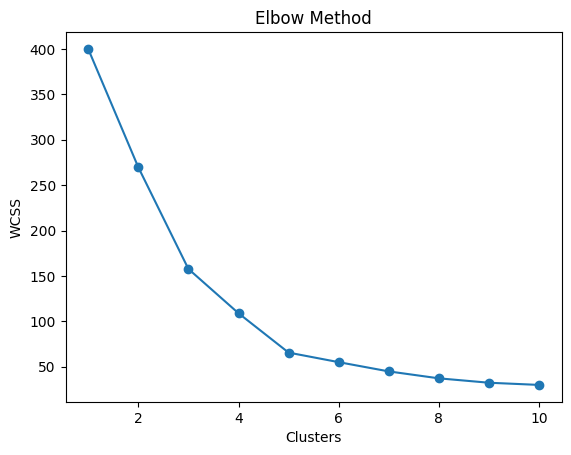

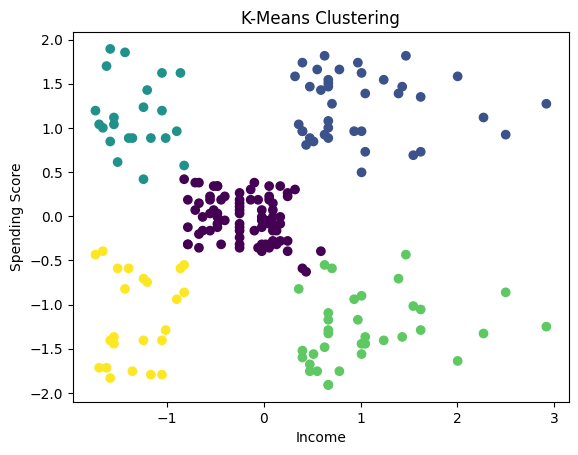

K-Means Silhouette Score: 0.5546571631111091


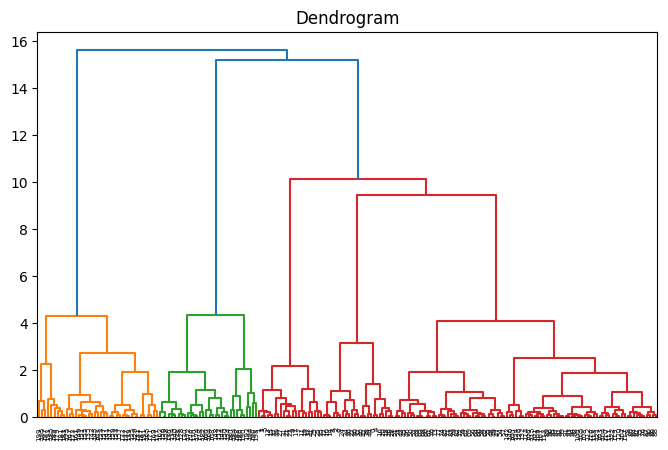

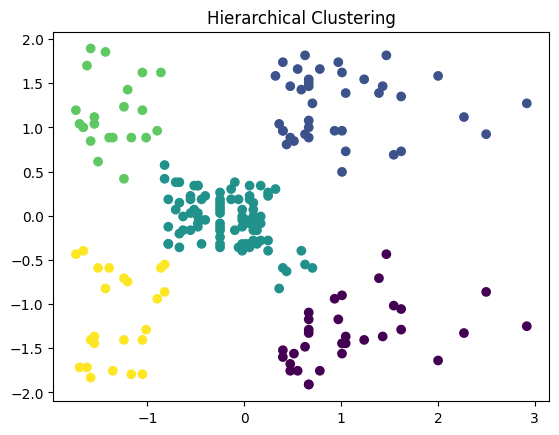

Hierarchical Silhouette Score: 0.5538089226688662


In [7]:
# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# LOAD DATASET
df = pd.read_csv('Mall_Customers.csv')

# CLEAN COLUMN NAMES
df.columns = df.columns.str.strip()

# SELECT FEATURES
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# SCALE DATA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# ELBOW METHOD
# -------------------------------
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.show()

# -------------------------------
# K-MEANS
# -------------------------------
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans)
plt.title('K-Means Clustering')
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.show()

print("K-Means Silhouette Score:", silhouette_score(X_scaled, y_kmeans))

# -------------------------------
# DENDROGRAM
# -------------------------------
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(8,5))
dendrogram(linked)
plt.title('Dendrogram')
plt.show()

# -------------------------------
# HIERARCHICAL
# -------------------------------
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
y_hc = hc.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_hc)
plt.title('Hierarchical Clustering')
plt.show()

print("Hierarchical Silhouette Score:", silhouette_score(X_scaled, y_hc))